In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/danielalvarezmorales/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/danielalvarezmorales/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/danielalvarezmorales/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Libraries loaded!


In [2]:
movies = pd.read_csv("/Users/danielalvarezmorales/movie-plots/data/wiki_movie_plots_deduped.csv")
movies_clean = movies[movies["Genre"] != "unkown"].copy()

Shape: (34886, 8)


In [7]:
# Tokenizing Plot Summaries
stop_words = set(stopwords.words('english'))

custom_stopwords = {'film', 'movie', 'one', 'two', 'man', 'woman', 'day', 
                    'time', 'back', 'later', 'also', 'told', 'tells', 'take',
                    'goes', 'get', 'gets', 'find', 'finds', 'make', 'makes', 'way', 
                    'see', 'say', 'know'}

stop_words.update(custom_stopwords)

def clean_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

print("Tokenizing plots...")
movies_clean['tokens'] = movies_clean['Plot'].apply(clean_text)
print("Done!")

all_tokens = [token for tokens in movies_clean['tokens'] for token in tokens]
print(f"Total tokens: {len(all_tokens):,}")

Tokenizing plots...
Done!
Total tokens: 6,738,448


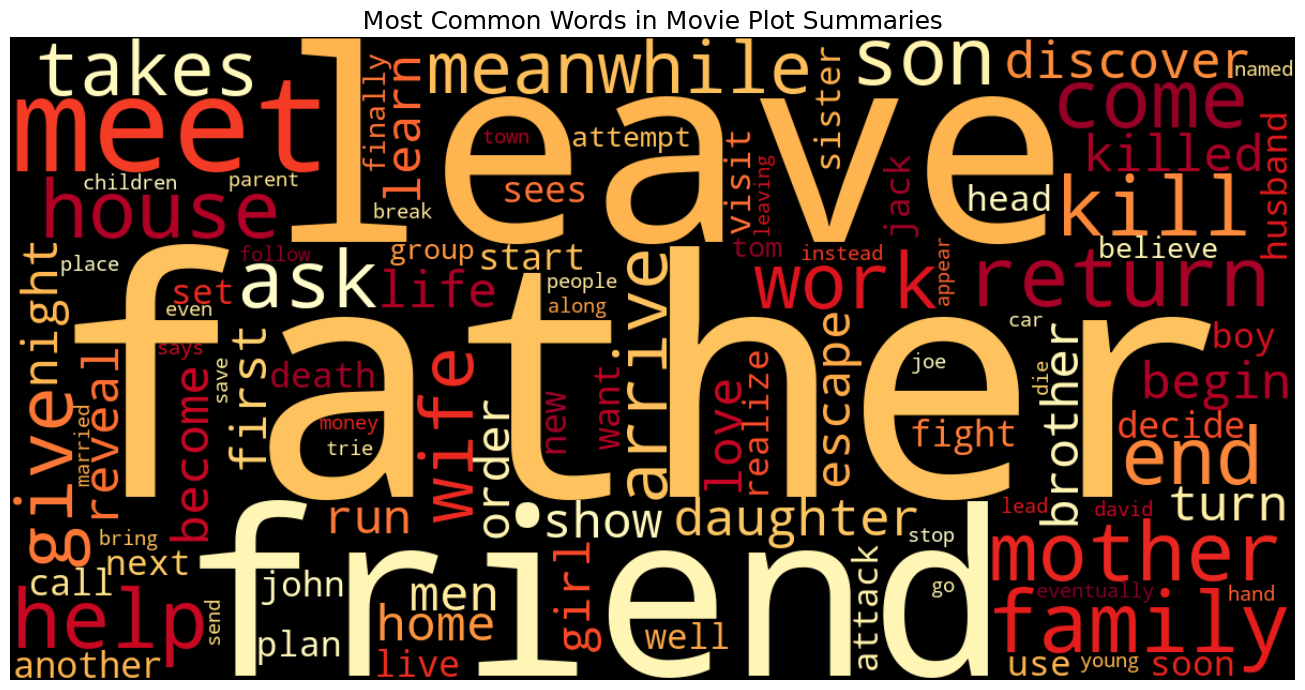

In [9]:
# Word Cloud of Most Common Words in Plot Summaries
text = ' '.join(all_tokens)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black',
    colormap='YlOrRd',
    max_words=100
).generate(text)

fig, ax = plt.subplots(figsize=(15, 7))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Movie Plot Summaries', fontsize=18)
plt.tight_layout()
plt.savefig('/Users/danielalvarezmorales/movie-plots/images/wordcloud.png', dpi=150)
plt.show()


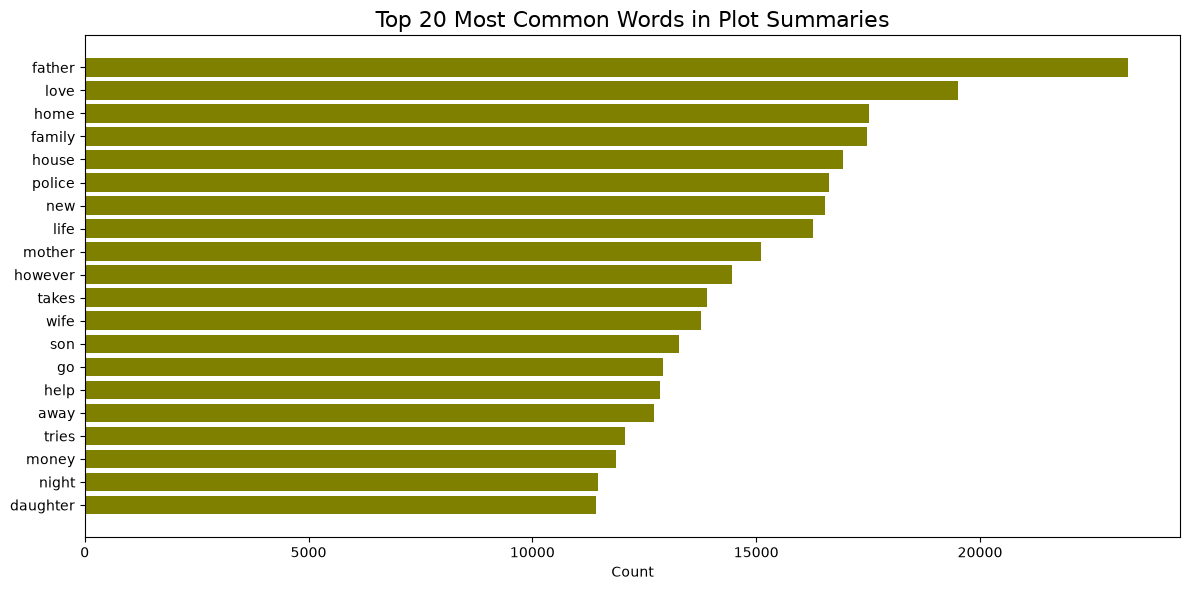

In [14]:
word_frequency = Counter(all_tokens)
top_20 = pd.DataFrame(word_frequency.most_common(20), columns = ['Word', 'Count'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_20['Word'], top_20['Count'], color='olive')
ax.set_title('Top 20 Most Common Words in Plot Summaries', fontsize=16)
ax.set_xlabel('Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('/Users/danielalvarezmorales/movie-plots/images/top_20_words.png', dpi=150)
plt.show()